# **✅ Task 10: KNN – Handwritten Digit Classification**

## **Importing Required Modules:**

In [188]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

## **Load digits dataset and view shapes of X and y to confirm dataset structure:**

In [189]:
data = load_digits()

In [190]:
X = pd.DataFrame(data.data,columns= data.feature_names)
X

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [191]:
y = pd.DataFrame(data.target,columns=['target'])

In [192]:
y = y.values.reshape(-1,1)

In [193]:
y

array([[0],
       [1],
       [2],
       ...,
       [8],
       [9],
       [8]])

In [194]:
X.shape,y.shape

((1797, 64), (1797, 1))

## **Visualize few digit images using matplotlib to confirm labels:**

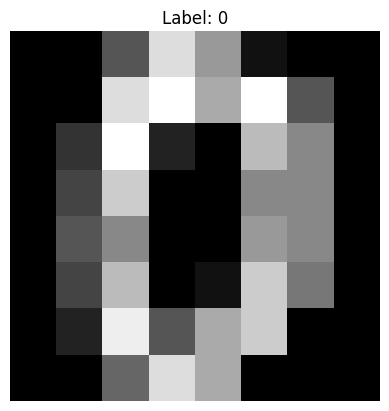

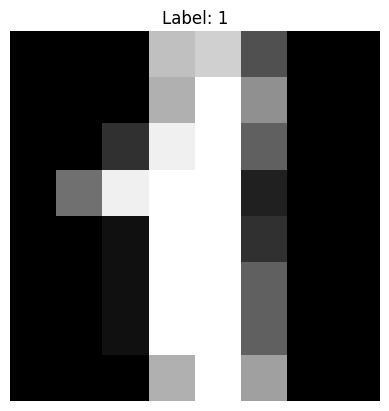

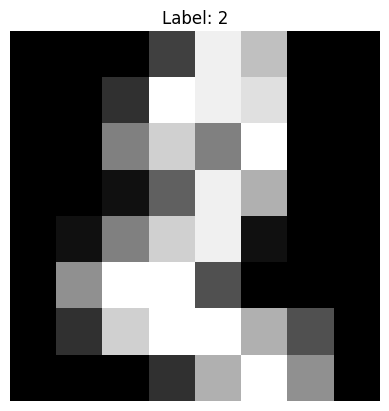

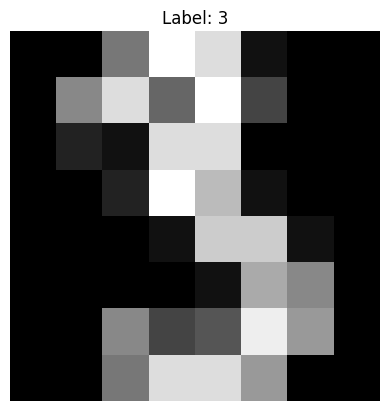

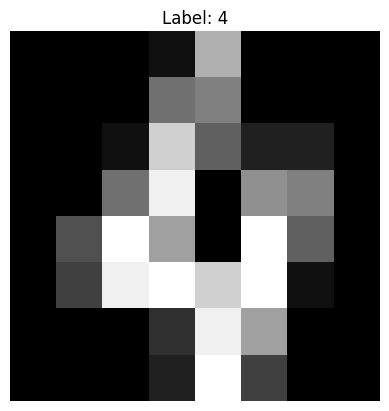

In [195]:
for i in range(5):
  image = data.data[i].reshape(8, 8)

  plt.imshow(image, cmap='gray')
  plt.title(f"Label: {data.target[i]}")
  plt.axis('off')
  plt.savefig(f'verification:{i + 1}:image.png')
  plt.show()

## **Split dataset into training and testing sets:**

In [196]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [197]:
y_train = y_train.ravel()
y_test = y_test.ravel()

In [198]:
X.isnull().sum().sum()

np.int64(0)

## **Apply feature scaling using StandardScaler since KNN uses distances:**

In [199]:
from sklearn.preprocessing import StandardScaler

In [200]:
scaler = StandardScaler()

In [201]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Train KNN model with K=3 and evaluate accuracy:**

In [202]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

In [203]:
model_3 = KNeighborsClassifier(n_neighbors = 3)

In [204]:
model_3.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=3)

## **Try multiple K values (3,5,7,9) and store results:**

In [205]:
results = []

In [206]:
y_pred_3 = model_3.predict(X_test_scaled)
accuracy_score(y_test,y_pred_3)

0.9694444444444444

In [207]:
results.append(
    {
        "K": 3,
        "Accuracy": accuracy_score(y_test,y_pred_3)
    }
)

In [208]:
k_values = [5, 7, 9]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "K": k,
        "Accuracy": accuracy
    })

In [209]:
results

[{'K': 3, 'Accuracy': 0.9694444444444444},
 {'K': 5, 'Accuracy': 0.975},
 {'K': 7, 'Accuracy': 0.9722222222222222},
 {'K': 9, 'Accuracy': 0.9722222222222222}]

## **Plot accuracy vs K graph to pick best K:**

In [211]:
results_df = pd.DataFrame(results)
results_df

,K,Accuracy
0,3,0.969444
1,5,0.975000
2,7,0.972222
3,9,0.972222


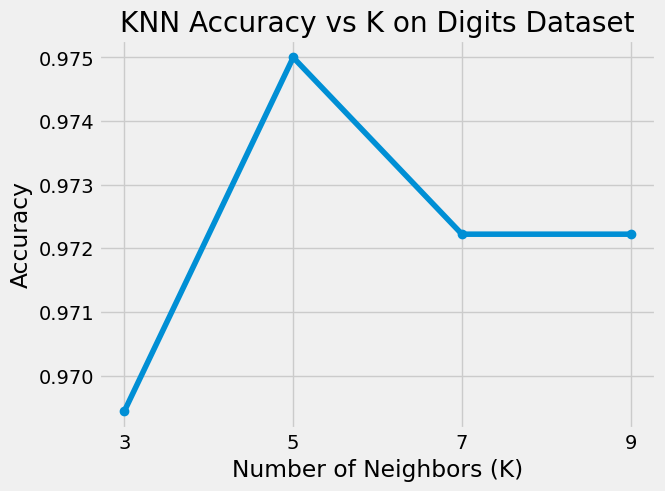

In [216]:
plt.style.use('fivethirtyeight')
plt.plot(results_df['K'], results_df['Accuracy'], marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K on Digits Dataset')
plt.xticks(results_df['K'])
plt.savefig('plot_k_vs_accuracy.png')
plt.show()

## **Generate confusion matrix to check misclassified digits:**

In [224]:
model_5 = KNeighborsClassifier(n_neighbors = 5)

In [225]:
model_5.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [227]:
y_pred_5 = model_5.predict(X_test_scaled)


In [228]:
confusion_matrix(y_test,y_pred_5)

array([[33,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 28,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 33,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1, 33,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0, 46,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 45,  1,  0,  0,  1],
       [ 0,  0,  0,  0,  0,  0, 35,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0, 32,  0,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 30,  0],
       [ 0,  0,  0,  1,  1,  1,  0,  0,  1, 36]])

## **Display 5 test images with predicted labels to show final output:**

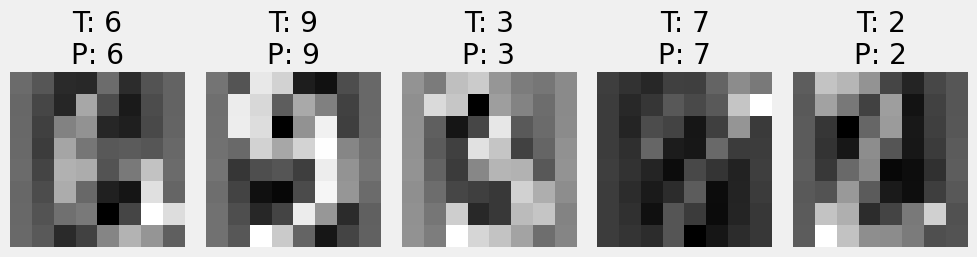

In [233]:
plt.figure(figsize=(10, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = X_test_scaled[i].reshape(8, 8)

    plt.imshow(image, cmap='gray')
    plt.title(f"T: {y_test[i]}\nP: {y_pred_5[i]}")
    plt.axis('off')

plt.tight_layout()
plt.savefig('Final_check_after_training.png')
plt.show()